# Dependencies

In [1]:
%pip install matplotlib
# conda
# !conda install -c conda-forge matplotlib

In [2]:
# cleanup
# !pip uninstall -y matplotlib

In [2]:
%matplotlib inline
import matplotlib
print(matplotlib.__version__)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

3.9.2


In [4]:
# common tools
import sys
from pathlib import Path
sys.path.append(Path.cwd().parent.as_posix())
# print(sys.path)

from ml_tools.common import *

# Coding Styles

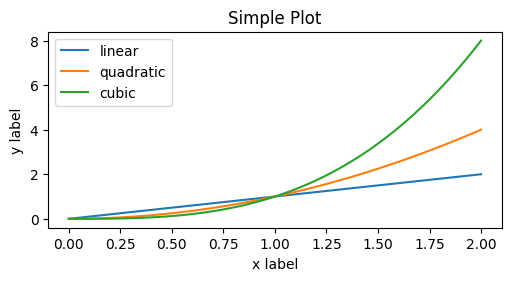

In [5]:
# OO-style

x = np.linspace(0, 2, 100)  # Sample data.

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained') # Figure, Axes
ax.plot(x, x, label='linear')  # Plot some data on the Axes.
ax.plot(x, x**2, label='quadratic')  # Plot more data on the Axes...
ax.plot(x, x**3, label='cubic')  # ... and some more.
ax.set_xlabel('x label')  # Add an x-label to the Axes.
ax.set_ylabel('y label')  # Add a y-label to the Axes.
ax.set_title("Simple Plot")  # Add a title to the Axes.
ax.legend()  # Add a legend.

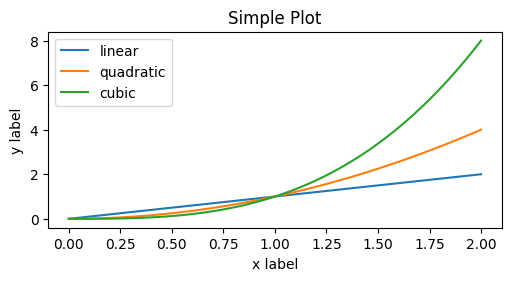

In [6]:
# pyplot-style

x = np.linspace(0, 2, 100)  # Sample data.

plt.figure(figsize=(5, 2.7), layout='constrained')
plt.plot(x, x, label='linear')  # Plot some data on the (implicit) Axes.
plt.plot(x, x**2, label='quadratic')  # etc.
plt.plot(x, x**3, label='cubic')
plt.xlabel('x label')
plt.ylabel('y label')
plt.title("Simple Plot")
plt.legend()

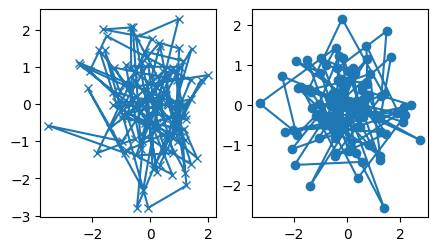

In [7]:
# helper functions

from matplotlib.pyplot import Axes, Line2D
from typing import Any


def my_plotter(ax: Axes, data1: Any, data2: Any, param_dict: dict) -> list[Line2D]:
  """
  A helper function to make a graph.
  """
  out = ax.plot(data1, data2, **param_dict)
  return out


data1, data2, data3, data4 = np.random.randn(4, 100)  # make 4 random data sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7))
my_plotter(ax1, data1, data2, {'marker': 'x'})
my_plotter(ax2, data3, data4, {'marker': 'o'})

# Plot Styles

## rcParams

In [8]:
params_dict = matplotlib.rcParams
pd_print([{"key": k, "value": v} for k, v in params_dict.items()])

,key,value
0,_internal.classic_mode,False
1,agg.path.chunksize,0
2,animation.bitrate,-1
3,animation.codec,h264
4,animation.convert_args,"[-layers, OptimizePlus]"
5,animation.convert_path,convert
6,animation.embed_limit,20.0
7,animation.ffmpeg_args,[]
8,animation.ffmpeg_path,ffmpeg
9,animation.frame_format,png


## style

In [9]:
mpl.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [ ]:
mpl.style.use('seaborn-v0_8')

In [36]:
mpl.style.use('default')

## colormaps

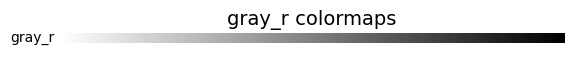

In [10]:
# https://matplotlib.org/stable/users/explain/colors/colormaps.html
# list(mpl.colormaps)

cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list

plot_color_gradients('gray_r', ['gray_r'])

# Modules

In [11]:
# inspect_submodules(mpl)
# inspect_classes(mpl.axes)

# Data Visualization in ML Workflow

## dataset exploratory

In [12]:
from sklearn.datasets import load_digits

digits = load_digits()
print(type(digits))

<class 'sklearn.utils._bunch.Bunch'>


In [13]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [14]:
print(digits['DESCR'])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [15]:
print(digits['data'].shape, digits['data'][0].shape)
print(digits['images'].shape, digits['images'][0].shape)
print(digits['target'].shape, digits['target_names'], digits['target'][:10])

(1797, 64) (64,)
(1797, 8, 8) (8, 8)
(1797,) [0 1 2 3 4 5 6 7 8 9] [0 1 2 3 4 5 6 7 8 9]


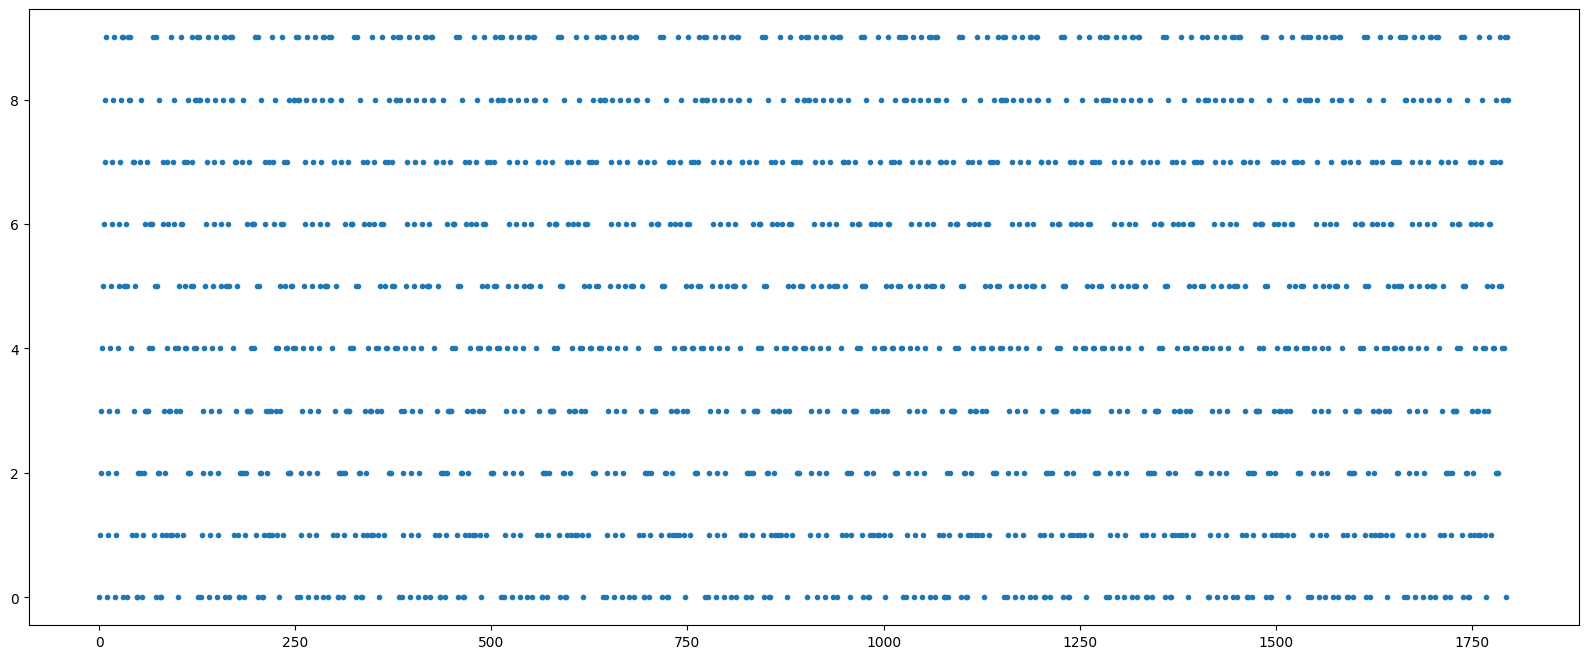

In [16]:
data_size = len(digits.target)

# examine randomness of dataset
with mpl.rc_context({'figure.figsize': [20, 8]}):
  plt.scatter(range(data_size), digits.target, marker='.')
  plt.show()

[0 1 2 3 4 5 6 7 8 9]


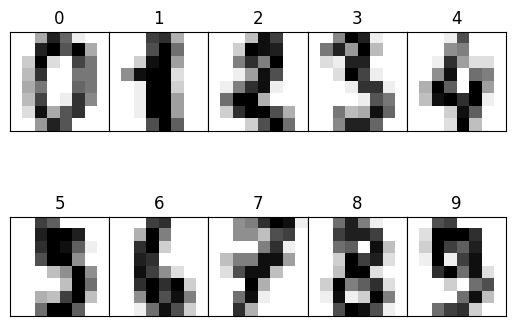

In [17]:
# draw sample digits

print(digits.target[:10])
rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols, sharex=True, sharey=True)
for i in range(rows):
  for j in range(cols):
    axes[i, j].imshow(digits.images[i*cols + j], cmap='gray_r')
    axes[i, j].set_xticks([])
    axes[i, j].set_yticks([])
    axes[i, j].set_title(digits.target[i*cols+j])

plt.subplots_adjust(wspace=0, hspace=0)

In [18]:
# t-SNE: reduce dimensions
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html#sklearn.manifold.TSNE
from sklearn.manifold import TSNE

pd_print(TSNE().get_params(deep=True))

,angle,early_exaggeration,init,learning_rate,max_iter,method,metric,metric_params,min_grad_norm,n_components,n_iter_without_progress,n_jobs,perplexity,random_state,verbose
0,0.5,12.0,pca,auto,1000,barnes_hut,euclidean,None,1.000000e-07,2,300,None,30.0,None,0


In [19]:
X = np.vstack([digits.data[digits.target == i] for i in range(10)])
y = np.hstack([digits.target[digits.target == i] for i in range(10)])


def fit(max_iter: int) -> None:
  tsne_iter = TSNE(init='pca', method='exact', n_components=2,
                   max_iter=max_iter).fit_transform(X)
  df = pd.DataFrame(tsne_iter)
  mpl.style.use('seaborn-v0_8')
  plt.scatter(df[0], df[1], c=y, cmap=mpl.colormaps.get_cmap('tab10'))
  plt.show()

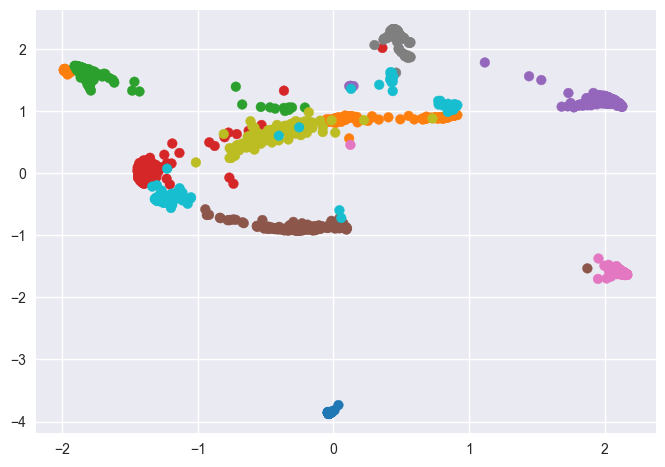

In [20]:
fit(250) # 16s

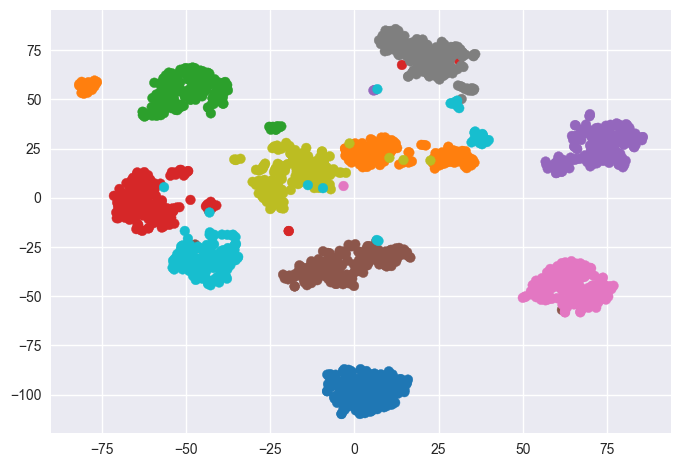

In [21]:
fit(2000) # 2m7s

In [38]:
mpl.style.use('default')

## model

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

from keras import Input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Convolution2D, MaxPooling2D
from keras import backend as K
from keras.callbacks import History

# split data
lb = LabelBinarizer()
# (1797, 8, 8) => (1797, 8, 8, 1)
X = np.expand_dims(digits.images.T, axis=0).T
# (1797,) => (1797, 10): one-hot encoding
y = lb.fit_transform(digits.target)  
print(X.shape, y.shape)
# print(X[0])
# print(y[0])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1797, 8, 8, 1) (1797, 10)
(1437, 8, 8, 1) (1437, 10) (360, 8, 8, 1) (360, 10)


In [23]:
# model
input_shape = (8, 8, 1)
model = Sequential([Input(shape=input_shape)])

K.set_image_data_format('channels_last')

model.add(Convolution2D(filters=4, kernel_size=(3, 3),
          padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dropout(0.05))
model.add(Dense(10, activation='softmax'))

# compile model
model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 4)        │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690 (2.70 KB)

 Trainable params: 690 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# history
history = History()
# fit model
model.fit(X_train, y_train, epochs=100, batch_size=128, callbacks=[history])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1125 - loss: 6.7205  
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1299 - loss: 4.7427 
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1575 - loss: 3.7522 
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1709 - loss: 3.1337 
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1589 - loss: 2.7923 
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1852 - loss: 2.5123 
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2064 - loss: 2.3240 
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2624 - loss: 2.1146 
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2860 - loss: 1.9923 
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3424 - loss: 1.8316 
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3740 - loss: 1.7169 
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

## evaluation

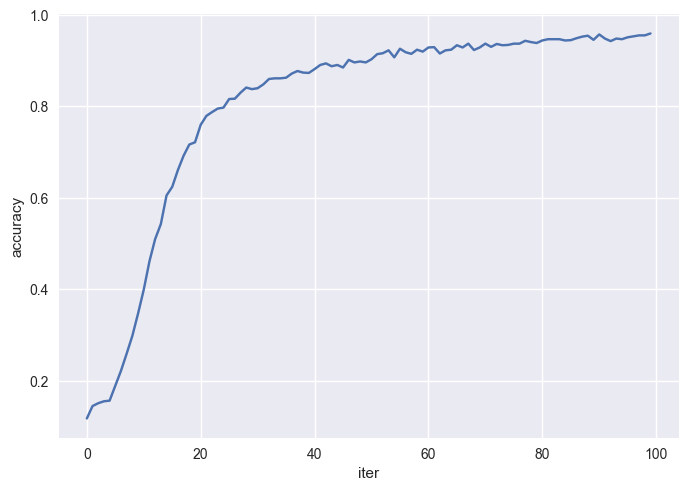

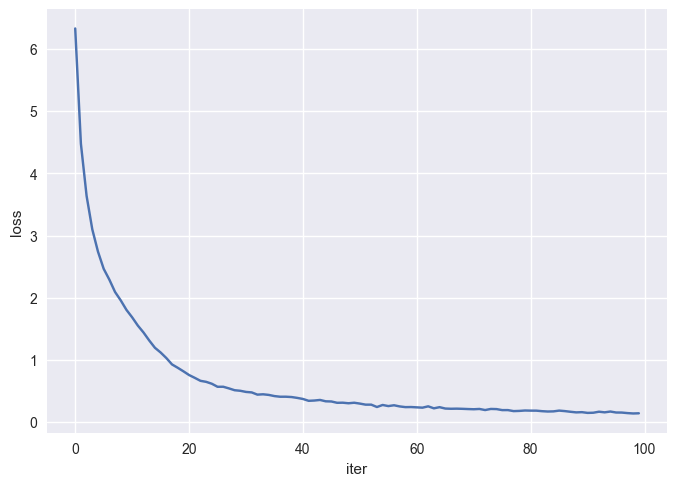

In [25]:
# history.history

_accuracy = history.history['accuracy']
_loss = history.history['loss']
_x = range(len(_accuracy))
plt.plot(_x, _accuracy)
plt.xlabel('iter')
plt.ylabel('accuracy')
plt.show()

plt.plot(_x, _loss)
plt.xlabel('iter')
plt.ylabel('loss')
plt.show()

## predication

In [26]:
# one-hot => integer
y_pred = model.predict(X_test)
y_pred = lb.fit_transform(np.round(y_pred))
y_pred = np.argmax(y_pred, axis=1)

y_actual = np.argmax(y_test, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [27]:
mis_index = np.arange(len(y_actual))[y_actual != y_pred]
true_targets = np.asarray([y_actual[i] for i in mis_index])
false_targets = np.asarray([y_pred[i] for i in mis_index])
print('mis index', mis_index)
print('actual', true_targets)
print('predicated', false_targets)

mis index [  6   8  34  43  55 117 146 160 188 189 192 291 294 323]
actual [7 7 5 2 8 4 8 2 2 8 4 7 6 8]
predicated [4 9 9 8 9 9 0 1 1 6 9 0 8 7]


14
3 5


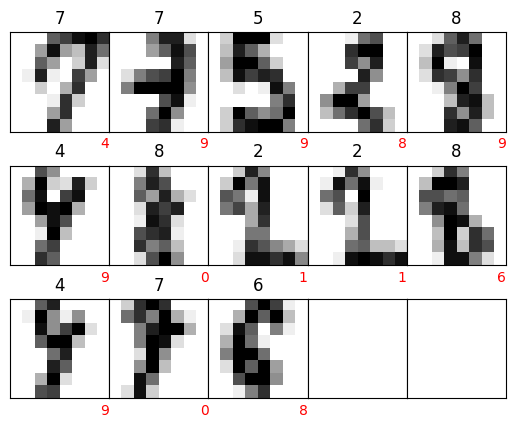

In [37]:
mis_size = len(mis_index)
print(mis_size)
cols = 5
if mis_size % cols == 0:
  rows = mis_size / cols
else:
  rows = (mis_size // cols) + 1
print(rows, cols)

fig, axes = plt.subplots(rows, cols, sharex=True, sharey=True)
for i in range(rows):
  for j in range(cols):
    idx = i * cols + j
    if idx >= mis_size - 1:
      axes[i, j].imshow(np.zeros((8,8)), cmap='gray_r')
    else:
      axes[i, j].imshow(X_test[mis_index[idx]].reshape(8,8), cmap='gray_r')
      axes[i, j].set_title(true_targets[idx])
      axes[i, j].set_xlabel(false_targets[idx], loc='right', color='red')
    axes[i, j].set_xticks([])
    axes[i, j].set_yticks([])

plt.subplots_adjust(wspace=0, hspace=0.3)

# Examples

## 子图绘制, 使用Figure/AxesSubplot上方法

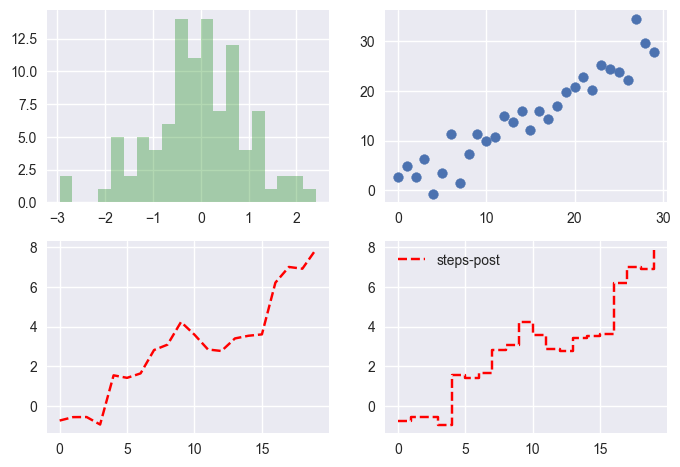

In [29]:
import numpy as np

fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
# 在ax3上绘制
cumsum = np.random.randn(20).cumsum();
plt.plot(cumsum, 'r--') # 非实际数据点默认按线性方式插值

ax4 = fig.add_subplot(2,2,4)
plt.plot(cumsum, 'r--', drawstyle='steps-post', label='steps-post') # drawstyle='steps-post' ???
plt.legend(loc='best') # 图例

# 在ax1上绘制, 直方图
_ = ax1.hist(np.random.randn(100), bins=20, color='g', alpha=0.3)
# 在ax2上绘制, 散点图
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))

#fig.show()

## 子图绘制, 使用matplotlib.pyplot方法

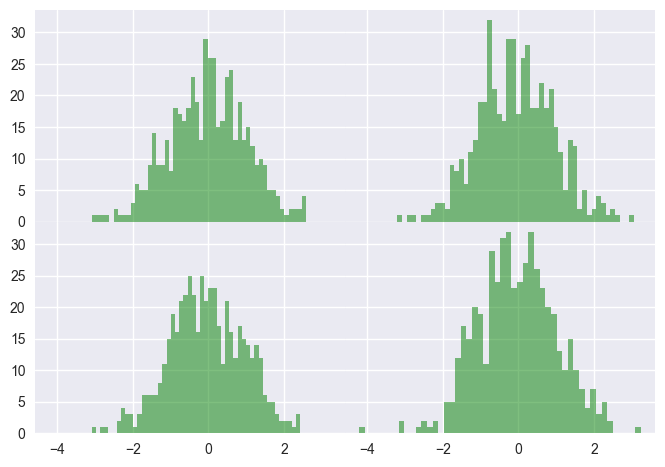

In [30]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True) # 所有子图
for i in range(2):
    for j in range(2):
        #axes[i,j].set_xlim([-5, 5]) # 设置范围
        axes[i,j].hist(np.random.randn(500), bins=50, color='g', alpha=0.5)
# 调整子图间的间距
plt.subplots_adjust(wspace=0, hspace=0)

## 设置标题, 轴标签, 刻度和刻度标签

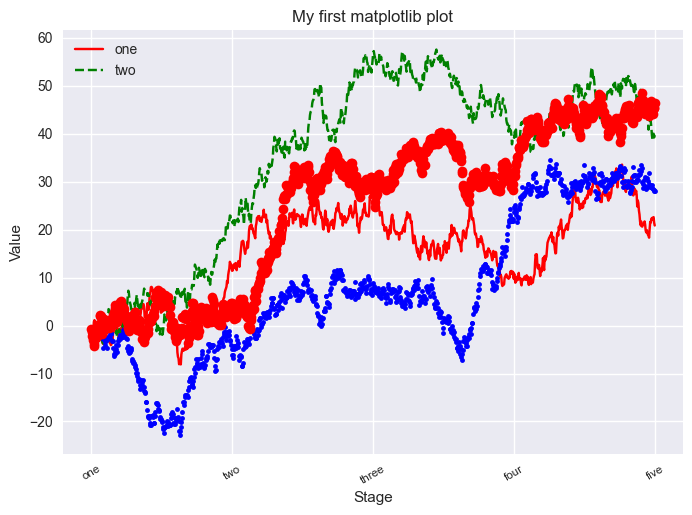

In [31]:
### 两种方式: plt.xlim(), AxesSubplot.set_xlim()
### 
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(np.random.randn(1000).cumsum(), 'r', label='one') # label用于图例
ax.plot(np.random.randn(1000).cumsum(), 'g--', label='two')
ax.plot(np.random.randn(1000).cumsum(), 'b.', label='_nolegend_') # 不纳入图例
ax.plot(np.random.randn(1000).cumsum(), 'ro') # 不纳入图例
# 刻度和刻度标签
ticks = ax.set_xticks([0,250,500,750,1000])
labels = ax.set_xticklabels(['one','two','three','four','five'], rotation=30, fontsize='small')
# 标题
ax.set_title('My first matplotlib plot')
# 轴标签
ax.set_xlabel('Stage')
ax.set_ylabel('Value')
# 图例(legend)
ax.legend(loc='best')

## 中文支持

In [5]:
import matplotlib.font_manager as fm

# matplotlib only know these fonts
font_list = [f for f in fm.fontManager.ttflist]

# check font names what you want
cjk_list = ['CJK']#['CJK', 'Han', 'CN', 'TW']

for f in font_list:
    if any(s.lower() in f.name.lower() for s in cjk_list):
        print(f'name={f.name}, path={f.fname}')

Text(0.5, 1.0, '中文标题')

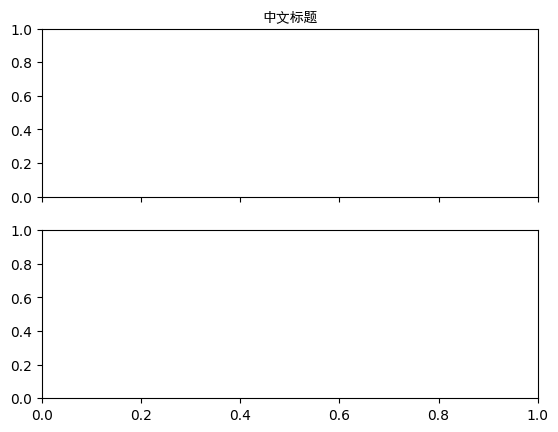

In [8]:
# import matplotlib
# matplotlib.font_manager._load_fontmanager(try_read_cache=False)

import matplotlib.font_manager as fm
# the location of the font file
# font_path = '/System/Library/Fonts/PingFang.ttc'
font_path = 'C:/Windows/Fonts/simhei.ttf' # simsun.ttc

# get the font based on the font_path
my_font = fm.FontProperties(fname=font_path)

fig, axes = plt.subplots(2, 1, sharex=True, sharey=True)
# axes[0].set_title(u'中文标题')
axes[0].set_title(u'中文标题', fontproperties=my_font)